# Graphic 3: Global Mean Estimates based on Land and Ocean Data

This notebook replicates the GISTEMP v4 graphic
[Global Mean Estimates based on Land and Ocean Data](https://data.giss.nasa.gov/gistemp/graphs_v4/graph_data/Global_Mean_Estimates_based_on_Land_and_Ocean_Data/graph.html).

The figure shows the annual global mean surface temperature anomaly (the
"Land-Ocean Temperature Index") relative to the 1951-1980 mean, together with
the red 5-year lowess smoothing that is commonly used to describe the trend.

**Data:** `data/global_annual_mean.csv` (GISTEMP v4).

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MultipleLocator

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## Load the data

The CSV contains two title lines before the header row.

In [2]:
df = pd.read_csv(DATA_DIR / "global_annual_mean.csv", skiprows=2,
                 names=["Year", "No_Smoothing", "Lowess"])
print("shape:", df.shape)
df.head()

shape: (146, 3)


,Year,No_Smoothing,Lowess
0,1880,-0.18,-0.10
1,1881,-0.09,-0.14
2,1882,-0.12,-0.18
3,1883,-0.18,-0.21
4,1884,-0.29,-0.25


In [3]:
df.tail()

,Year,No_Smoothing,Lowess
141,2021,0.85,1.01
142,2022,0.89,1.07
143,2023,1.17,1.12
144,2024,1.29,1.17
145,2025,1.19,1.23


## Build the figure

The annual means are drawn as a thin black line with square markers and the
lowess smoothing as a thick red line, matching the original graphic.

> **Note on the uncertainty band.** The official NASA figure also shows a
> light-grey *LSAT+SST Uncertainty* band. That band is not part of
> `graph.csv` (it comes from a separate GISTEMP uncertainty product,
> Lenssen et al., 2024), so it is not included in this replication.

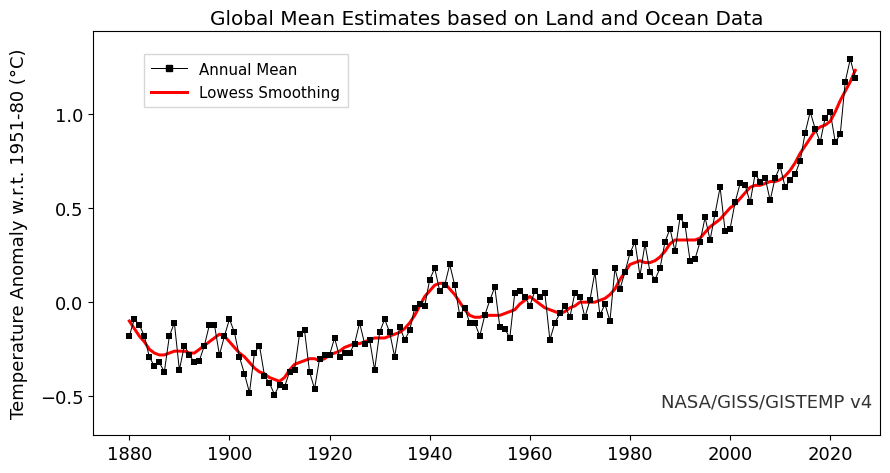

In [4]:
fig = plt.figure(figsize=(9.04, 4.8), dpi=100)
ax = fig.add_axes([0.1158, 0.0812, 0.8709, 0.8432])

ax.plot(df.Year, df.No_Smoothing, color="#000000", lw=0.72,
        marker="s", ms=4.3, mew=0, zorder=3)
ax.plot(df.Year, df.Lowess, color="#FF0000", lw=2.16, zorder=2)

ax.set_xlim(1872.75, 2030)
ax.set_ylim(-0.7064, 1.4415)
ax.set_xticks(range(1880, 2021, 20))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.tick_params(labelsize=12.96)

ax.text(0.5, 1.016, "Global Mean Estimates based on Land and Ocean Data",
        transform=ax.transAxes, ha="center", va="baseline", fontsize=14.4)
ax.text(-0.094, 0.5, "Temperature Anomaly w.r.t. 1951-80 (\N{DEGREE SIGN}C)",
        transform=ax.transAxes, ha="center", va="center", rotation=90,
        fontsize=12.96)
ax.text(0.99, 0.07, "NASA/GISS/GISTEMP v4", transform=ax.transAxes,
        ha="right", va="baseline", fontsize=12.96, alpha=0.8)

handles = [
    Line2D([], [], color="#000000", lw=0.72, marker="s", ms=4.3),
    Line2D([], [], color="#FF0000", lw=2.16),
]
ax.legend(handles, ["Annual Mean", "Lowess Smoothing"], loc="upper left",
          bbox_to_anchor=(0.055, 0.96), fontsize=10.8, framealpha=0.8,
          edgecolor="#cccccc", fancybox=False, labelspacing=0.55,
          borderpad=0.5, handlelength=2.4)

## Save and display

In [5]:
fig.savefig(OUTPUT_DIR / "graphic3_global_annual_mean.png", dpi=100)
fig.savefig(OUTPUT_DIR / "graphic3_global_annual_mean.pdf")
plt.show()

The annual values fluctuate around the smoothed trend, but the trend itself
is unmistakable: about 1.2 °C of warming relative to the 1951-1980 mean by
2025. This figure is also the basis of the New York Times graphic replicated
in notebook 4.